In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [6]:
df = pd.read_csv("../data/Groceries_dataset.csv")

df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [9]:
te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Beer,Bread,Butter,Chips,Eggs,Milk
0,False,True,True,False,False,True
1,True,False,False,True,False,False
2,False,False,False,False,True,True
3,False,True,True,False,False,False


In [10]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.25,frozenset({Beer})
1,0.50,frozenset({Bread})
2,0.50,frozenset({Butter})
3,0.25,frozenset({Chips})
4,0.25,frozenset({Eggs})


In [11]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Beer}),frozenset({Chips}),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.000000,1.0,1.0
1,frozenset({Chips}),frozenset({Beer}),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.0,1.000000,1.0,1.0
2,frozenset({Bread}),frozenset({Butter}),0.50,0.50,0.50,1.0,2.0,1.0,0.2500,inf,1.0,1.000000,1.0,1.0
3,frozenset({Butter}),frozenset({Bread}),0.50,0.50,0.50,1.0,2.0,1.0,0.2500,inf,1.0,1.000000,1.0,1.0
4,frozenset({Bread}),frozenset({Milk}),0.50,0.50,0.25,0.5,1.0,1.0,0.0000,1.0,0.0,0.333333,0.0,0.5


In [12]:
strong_rules = rules[
    (rules['confidence'] > 0.5) &
    (rules['lift'] > 1)
]

strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Beer}),frozenset({Chips}),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.000000,1.0,1.0,1.00
1,frozenset({Chips}),frozenset({Beer}),0.25,0.25,0.25,1.0,4.0,1.0,0.1875,inf,1.000000,1.0,1.0,1.00
2,frozenset({Bread}),frozenset({Butter}),0.50,0.50,0.50,1.0,2.0,1.0,0.2500,inf,1.000000,1.0,1.0,1.00
3,frozenset({Butter}),frozenset({Bread}),0.50,0.50,0.50,1.0,2.0,1.0,0.2500,inf,1.000000,1.0,1.0,1.00
9,frozenset({Eggs}),frozenset({Milk}),0.25,0.50,0.25,1.0,2.0,1.0,0.1250,inf,0.666667,0.5,1.0,0.75
11,"frozenset({Bread, Milk})",frozenset({Butter}),0.25,0.50,0.25,1.0,2.0,1.0,0.1250,inf,0.666667,0.5,1.0,0.75
12,"frozenset({Milk, Butter})",frozenset({Bread}),0.25,0.50,0.25,1.0,2.0,1.0,0.1250,inf,0.666667,0.5,1.0,0.75


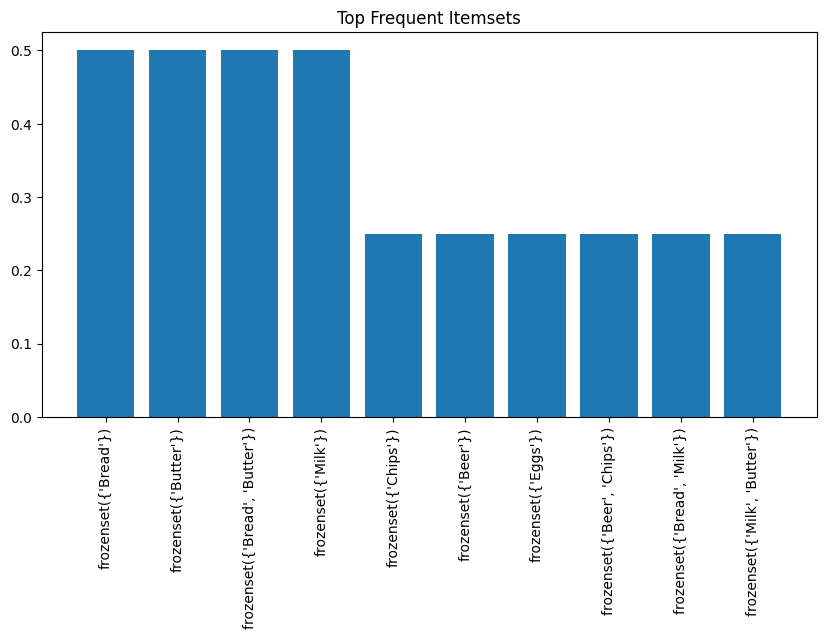

In [17]:
top_items = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    top_items['itemsets'].astype(str).head(10),
    top_items['support'].head(10)
)

plt.xticks(rotation=90)

plt.title("Top Frequent Itemsets")

# Save image
plt.savefig("../images/top_items.png", bbox_inches='tight')

# Show graph
plt.show()

In [18]:
print(frequent_itemsets.shape)

(12, 2)
